c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


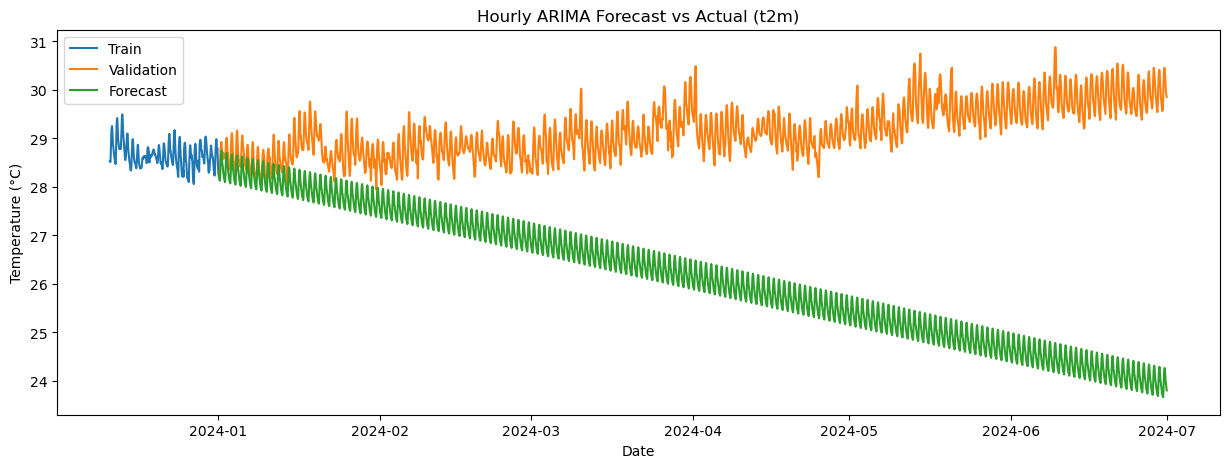

MAE: 2.996903202925618
RMSE: 3.4530384085542805


c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


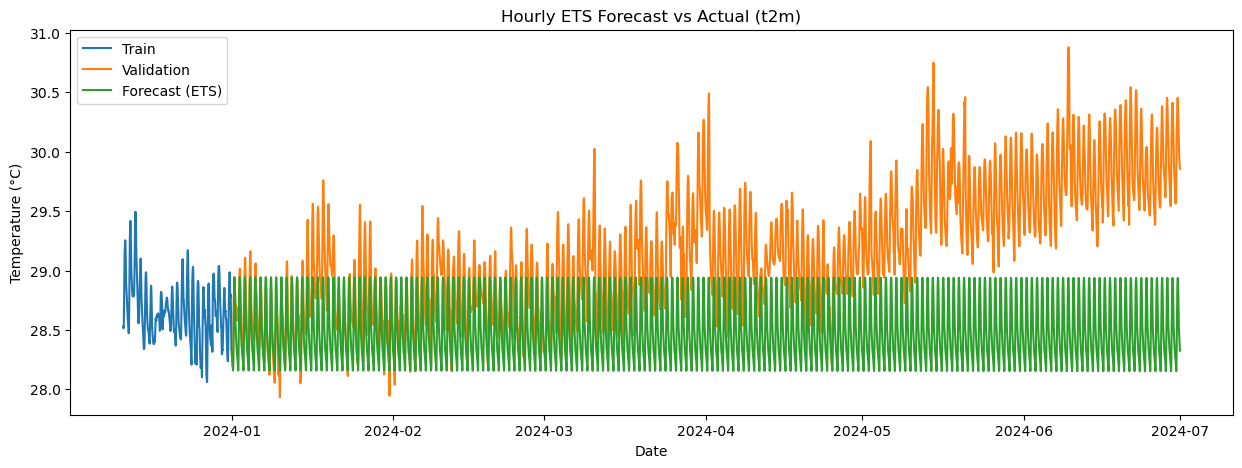

MAE: 0.6758860971996334
RMSE: 0.8186317032515644


22:54:27 - cmdstanpy - INFO - Chain [1] start processing
22:54:51 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


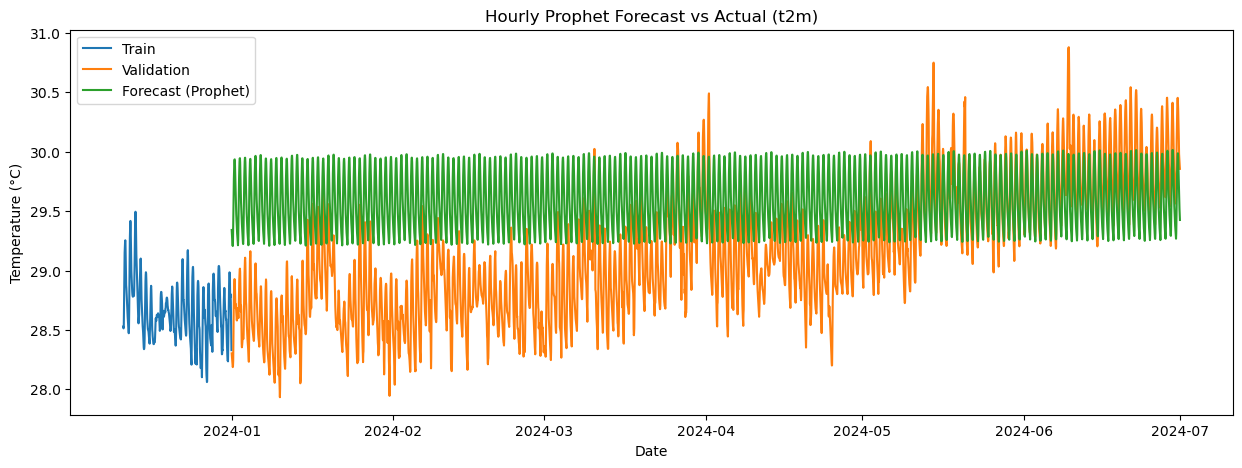

MAE: 0.5376076624880369
RMSE: 0.6284712142399763


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from prophet.plot import plot_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

train = df.loc[:'2023-12-31']['t2m']
val = df.loc['2024-01-01':'2024-06-30']['t2m']

# ARIMA for t2m
train = df.loc[:'2023-12-31']['t2m']
val = df.loc['2024-01-01':'2024-06-30']['t2m']

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24))
model_fit = model.fit(disp=False)

forecast = model_fit.predict(start=val.index[0], end=val.index[-1], dynamic=False)

plt.figure(figsize=(15,5))
plt.plot(train[-500:], label='Train')
plt.plot(val, label='Validation')
plt.plot(forecast, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly ARIMA Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae = mean_absolute_error(val, forecast)
rmse = np.sqrt(mean_squared_error(val, forecast))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

## ETS Baseline for Hourly Forecasting (t2m)
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=24)
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(val))

plt.figure(figsize=(15,5))
plt.plot(train[-500:], label='Train')
plt.plot(val, label='Validation')
plt.plot(forecast, label='Forecast (ETS)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly ETS Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae = mean_absolute_error(val, forecast)
rmse = np.sqrt(mean_squared_error(val, forecast))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

# Prophet for t2m

train = df.loc[:'2023-12-31'].reset_index()
val = df.loc['2024-01-01':'2024-06-30'].reset_index()

prophet_df = train.rename(columns={"valid_time": "ds", "t2m": "y"})
prophet_df = prophet_df[['ds', 'y']]

model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=len(val), freq='H')
forecast = model.predict(future)

forecasted_vals = forecast.iloc[-len(val):]['yhat'].values

plt.figure(figsize=(15,5))
plt.plot(train['valid_time'][-500:], train['t2m'][-500:], label='Train')
plt.plot(val['valid_time'], val['t2m'], label='Validation')
plt.plot(val['valid_time'], forecasted_vals, label='Forecast (Prophet)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly Prophet Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae = mean_absolute_error(val['t2m'], forecasted_vals)
rmse = np.sqrt(mean_squared_error(val['t2m'], forecasted_vals))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")





